# Text-to-SVG Generation — Training Notebook
**Course:** CS-GY 9223 Deep Learning — Spring 2026, NYU Tandon  
**Competition:** NYU Deep Learning Spring 2026 Kaggle Contest  
**Task:** Generate valid SVG code from natural language text prompts

## Training Overview

This notebook covers the full training pipeline for our text-to-SVG
generation model. It should be run in Google Colab with GPU enabled.

The notebook is structured as follows:

1. **Setup and Imports** — load libraries and set random seeds
2. **Data Loading and Cleaning** — download and preprocess training data
3. **Data Preparation** — tokenize prompts and SVG strings
4. **Model Setup** — load pretrained model and configure for fine-tuning
5. **Training** — run training loop and save best checkpoints
6. **Validation** — evaluate on held-out validation set

**Important notes:**
- Runtime: Runtime → Change Runtime Type → GPU before running
- All weights are saved to Google Drive to persist across sessions
- Random seed is fixed at 42 for reproducibility

## Key Findings from EDA

Based on our exploratory data analysis the following properties of
the dataset inform our training decisions:

- Prompts average ~20 words — T5-base or CLIP text encoder is sufficient
- SVGs are short and simple — majority under 2,000 characters and 50 paths
- Dataset is icon-focused and monochromatic — model does not need to
  handle complex scenes
- Canvas sizes vary in training data — 256x256 normalization handled
  at inference time
- Final clean training set after preprocessing: 45,130 rows

In [ ]:
!pip install -q "datasets>=3.4.1,<4.4.0" "pyarrow>=14.0.0"


In [ ]:
# ================================
# Section 1: Setup and Imports
# ================================

# core libraries
import os
import re
import random
import numpy as np
import pandas as pd

# deep learning
import torch

# set random seeds — required for reproducibility
# competition guide requires fixed random seeds in all code
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


In [ ]:
# verify GPU is available before doing anything
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected — go to Runtime → Change Runtime Type → T4 GPU")

GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 42.4 GB


In [ ]:
# ================================
# Section 2: Kaggle Setup
# ================================

from google.colab import files
files.upload()  # upload kaggle.json when prompted
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install kaggle

Saving kaggle.json to kaggle (1).json


In [ ]:
# download competition data
!kaggle competitions download -c dl-spring-2026-svg-generation



100% 32.4M/32.4M [00:00<00:00, 157MB/s]



In [ ]:
# unzip
import zipfile
with zipfile.ZipFile('dl-spring-2026-svg-generation.zip', 'r') as z:
    z.extractall('data/')

print(os.listdir('data/'))

['test.csv', 'sample_submission.csv', 'train.csv']


In [ ]:
# load raw data
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Raw training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

Raw training rows: 50000
Test rows: 1000


In [ ]:
train_df['prompt_len'] = train_df['prompt'].str.split().str.len()

non_ascii = train_df['prompt'].str.contains('[^\x00-\x7F]')
very_short = train_df['prompt_len'] < 3

print("=== BEFORE CLEANING ===")
print(f"Total rows: {len(train_df)}")
print(f"Non-ASCII prompts: {non_ascii.sum()}")
print(f"Under 3 word prompts: {very_short.sum()}")

train_clean = train_df[~(non_ascii | very_short)].reset_index(drop=True)
train_clean = train_clean.drop(columns=['prompt_len'])

print("\n=== AFTER CLEANING ===")
print(f"Clean training rows: {len(train_clean)}")
assert len(train_clean) == 49195, f"Expected 49195 rows but got {len(train_clean)}"
print("Assertion passed — correct number of rows confirmed")

=== BEFORE CLEANING ===
Total rows: 50000
Non-ASCII prompts: 794
Under 3 word prompts: 20

=== AFTER CLEANING ===
Clean training rows: 49195
Assertion passed — correct number of rows confirmed


#  Section 3 — Data Preparation (tokenization)

In [ ]:
!pip install -q -U pyarrow
!pip install -q unsloth
!pip install -q trl datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 55.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

MODEL_NAME  = 'unsloth/Qwen3.5-2B'
MAX_SEQ_LEN = 512
VAL_SPLIT   = 0.10

SYSTEM_PROMPT = (
    "You generate compact, valid SVG markup from user requests. "
    "Given a text description, output only SVG code with a single root <svg> element."
    "The SVG must use a 256x256 canvas, contain no scripts or animations, "
    "and use only standard SVG elements. Output the SVG and nothing else."
)

def format_example(prompt: str, svg: str) -> str:
    """
    Format one training example as a Qwen ChatML string.
    SFTTrainer will tokenize this and automatically mask the
    prompt tokens so loss is only computed on the SVG output.
    """
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\nGenerate SVG for: {prompt}<|im_end|>\n"
        f"<|im_start|>assistant\n{svg}<|im_end|>"
    )


train_df_split, val_df_split = train_test_split(
    train_clean,
    test_size=VAL_SPLIT,
    random_state=SEED,
)
train_df_split = train_df_split.reset_index(drop=True)
val_df_split   = val_df_split.reset_index(drop=True)

print(f"Train samples : {len(train_df_split):,}")
print(f"Val   samples : {len(val_df_split):,}")


train_dataset = Dataset.from_dict({
    'text': [
        format_example(row['prompt'], row['svg'])
        for _, row in train_df_split.iterrows()
    ]
})
val_dataset = Dataset.from_dict({
    'text': [
        format_example(row['prompt'], row['svg'])
        for _, row in val_df_split.iterrows()
    ]
})

print(f"\nSample formatted example (truncated):")
print(train_dataset[0]['text'][:300], '...')

Train samples : 44,275
Val   samples : 4,920

Sample formatted example (truncated):
<|im_start|>system
You generate compact, valid SVG markup from user requests. Given a text description, output only SVG code with a single root <svg> element.The SVG must use a 256x256 canvas, contain no scripts or animations, and use only standard SVG elements. Output the SVG and nothing else.<|im_ ...


# Section 4 — Model Setup (load T5)

In [ ]:
from unsloth import FastLanguageModel

print(f"Loading base model: {MODEL_NAME}")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0, # from 0.05 b/c Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj',
    ],
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=SEED,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters    : {total_params / 1e6:.1f} M")
print(f"Trainable (LoRA)    : {trainable_params / 1e6:.1f} M  "
      f"({100 * trainable_params / total_params:.2f} %)")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading base model: unsloth/Qwen3.5-2B
==((====))==  Unsloth 2026.3.15: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/336 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Unsloth: Making `model.base_model.model.model.language_model` require gradients

Total parameters    : 1386.8 M
Trainable (LoRA)    : 10.9 M  (0.79 %)


# Section 5 — Training Loop

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from google.colab import drive # drive to store and mount in google drive

drive.mount('/content/drive')

# SAVE_DIR = '/content/svg_qwen_lora'
SAVE_DIR = '/content/drive/MyDrive/svg_qwen_lora_v2'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Checkpoints will be saved to: {SAVE_DIR}\n")

print("WARNING: Colab local storage is wiped when the session ends.")
print("Before closing, download by running:")
print("    from google.colab import files")
print(f"    files.download('{SAVE_DIR}/best_adapter')")

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/svg_qwen_lora_v2

Before closing, download by running:
    from google.colab import files
    files.download('/content/drive/MyDrive/svg_qwen_lora_v2/best_adapter')


In [ ]:
import trl
print(trl.__version__)

0.24.0


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# training the model

# clear cache if needed
# import torch
# import gc
# gc.collect()
# torch.cuda.empty_cache()

training_args = TrainingArguments(
    max_steps = 1000, #  1000 for short training times and steps
    output_dir=SAVE_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=4, # speeds up eval 4x
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8, # reduce accumulation steps to 8 from 16 ( before was 2 * 8 = 16 but more stable)
    warmup_steps = int(0.05 * 1000), # changed the warm up steps to reflect the max 300 set from 8304
    learning_rate=1e-4, # changed the learning rate from 2e-4 to 1e-4 for this model to test
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=50, # log steps every 25 since we have short max steps from 50
    eval_strategy='steps',
    eval_steps=100, # eval every 25 steps
    save_strategy='steps',
    save_steps=100, # save every 25 steps
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    seed=SEED,
    report_to='none',
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer, # changed from tokenizer
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    # dataset_text_field='text',
    # max_seq_length=MAX_SEQ_LEN,
    # dataset_num_proc=2,
    args=training_args,
)

print("Starting training ...")
trainer_stats = trainer.train()

print(f"\nTraining complete.")
print(f"  Runtime    : {trainer_stats.metrics['train_runtime']:.0f} s")
print(f"  Train loss : {trainer_stats.metrics['train_loss']:.4f}")

# save best
adapter_path = os.path.join(SAVE_DIR, 'best_adapter')
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"\nLoRA adapter saved to: {adapter_path}")
adapter_size = sum(
    os.path.getsize(os.path.join(adapter_path, f))
    for f in os.listdir(adapter_path)
)
print(f"Adapter size: {adapter_size / 1e6:.1f} MB")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/44275 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/4920 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.


Starting training ...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,275 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 10,911,744 of 2,224,153,408 (0.49% trained)


Step,Training Loss,Validation Loss
100,0.404349,0.380747
200,0.347272,0.353946
300,0.338645,0.341813
400,0.326430,0.335108
500,0.325699,0.330835
600,0.313719,0.326412
700,0.318243,0.323674
800,0.312259,0.321978
900,0.321293,0.321080
1000,0.314319,0.320902


Unsloth: Not an error, but Qwen3_5ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



Training complete.
  Runtime    : 21460 s
  Train loss : 0.3458

LoRA adapter saved to: /content/drive/MyDrive/svg_qwen_lora_v2/best_adapter
Adapter size: 63.7 MB


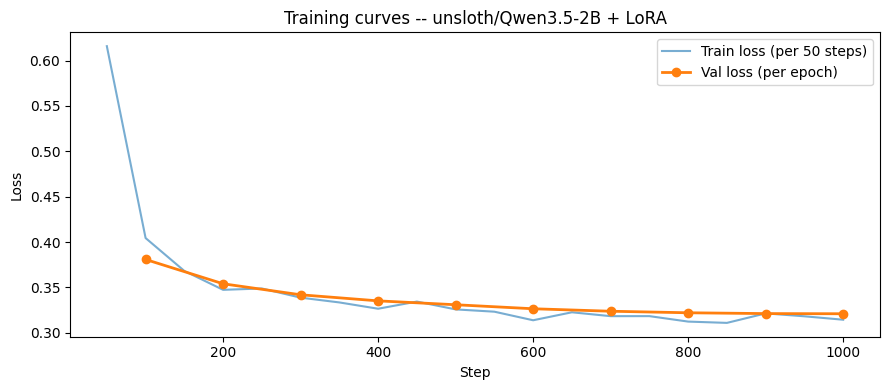

Curve saved.


In [ ]:
import matplotlib.pyplot as plt

log_history  = trainer.state.log_history
train_steps  = [x['step']      for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss']      for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step']      for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(9, 4))
plt.plot(train_steps, train_losses, alpha=0.6, label='Train loss (per 50 steps)')
plt.plot(eval_steps,  eval_losses,  'o-', linewidth=2, label='Val loss (per epoch)')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training curves -- {MODEL_NAME} + LoRA')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()
print("Curve saved.")

# Section 6 — Validation

In [ ]:
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm

# switch model to fast inference mode
# FastLanguageModel.for_inference() re-patches the model for 2x faster generation
FastLanguageModel.for_inference(model)
DEVICE = next(model.parameters()).device
print(f"Inference device: {DEVICE}")

# competition constants
ALLOWED_TAGS = {
    'svg', 'g', 'path', 'rect', 'circle', 'ellipse',
    'line', 'polyline', 'polygon', 'defs', 'use',
    'symbol', 'clipPath', 'mask', 'linearGradient',
    'radialGradient', 'stop', 'text', 'tspan', 'title',
    'desc', 'style', 'pattern', 'marker', 'filter',
}
MAX_SVG_LEN  = 16_000
MAX_PATH_CNT = 256


def validate_svg(svg_str: str):
    """Run all five competition checks. Returns (is_valid, reason_or_None)."""
    if len(svg_str) > MAX_SVG_LEN:
        return False, 'too_long'
    try:
        root = ET.fromstring(svg_str)
    except ET.ParseError:
        return False, 'parse_error'
    root_tag = root.tag.split('}')[-1] if '}' in root.tag else root.tag
    if root_tag != 'svg':
        return False, 'wrong_root_tag'
    for elem in root.iter():
        tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
        if tag not in ALLOWED_TAGS:
            return False, f'disallowed_tag:{tag}'
    path_count = sum(
        1 for e in root.iter()
        if (e.tag.split('}')[-1] if '}' in e.tag else e.tag) == 'path'
    )
    if path_count > MAX_PATH_CNT:
        return False, 'too_many_paths'
    return True, None


def extract_svg(full_output: str) -> str:
    """
    Extract just the SVG string from the model's full output.
    The model may add commentary before or after the SVG --
    we grab the first <svg...>...</svg> block only.
    """
    match = re.search(r'(<svg[\s\S]*?</svg>)', full_output, re.IGNORECASE)
    return match.group(1).strip() if match else full_output.strip()

Inference device: cuda:0


In [ ]:
# Experiment 1 (default): greedy -- fastest, good baseline
# Experiment 2: set num_beams=4 for beam search
DECODE_KWARGS = dict(
    max_new_tokens=900,  # SVGs are rarely >900 tokens
    do_sample=False,     # greedy decoding
    temperature=1.0,
    use_cache=True,
)

VAL_INFERENCE_BATCH = 8
val_prompts_list    = val_df_split['prompt'].tolist()
val_results         = []

for start in tqdm(range(0, len(val_prompts_list), VAL_INFERENCE_BATCH),
                  desc='Validating'):
    batch_prompts = val_prompts_list[start : start + VAL_INFERENCE_BATCH]

    # build prompt-only strings (no assistant turn -- model will generate it)
    prompt_strings = [
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\nGenerate SVG for: {p}<|im_end|>\n"
        f"<|im_start|>assistant\n"
        for p in batch_prompts
    ]

    inputs = tokenizer(
        prompt_strings,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LEN,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(**inputs, **DECODE_KWARGS)

    # decode only the newly generated tokens (exclude the prompt)
    prompt_len = inputs['input_ids'].shape[1]
    new_ids    = output_ids[:, prompt_len:]
    outputs    = tokenizer.batch_decode(new_ids, skip_special_tokens=True)

    for prompt, raw_output in zip(batch_prompts, outputs):
        svg              = extract_svg(raw_output)
        is_valid, reason = validate_svg(svg)
        val_results.append({
            'prompt':        prompt,
            'generated_svg': svg,
            'is_valid':      is_valid,
            'fail_reason':   reason,
        })

print(f"Inference complete -- {len(val_results)} samples evaluated.")

Validating:   0%|          | 0/615 [00:00<?, ?it/s]

ValueError: Incorrect image source. Must be a valid URL starting with `http://` or `https://`, a valid path to an image file, or a base64 encoded string. Got <|im_start|>system
You generate compact, valid SVG markup from user requests. Given a text description, output only SVG code with a single root <svg> element.The SVG must use a 256x256 canvas, contain no scripts or animations, and use only standard SVG elements. Output the SVG and nothing else.<|im_end|>
<|im_start|>user
Generate SVG for: A chef's hat sill out lines using black color.<|im_end|>
<|im_start|>assistant
. Failed with Invalid base64-encoded string: number of data characters (321) cannot be 1 more than a multiple of 4

In [ ]:
from collections import Counter

results_df = pd.DataFrame(val_results)
n_total    = len(results_df)
n_valid    = results_df['is_valid'].sum()
pct_valid  = 100.0 * n_valid / n_total

print("=" * 50)
print("       VALIDATION VALIDITY REPORT")
print("=" * 50)
print(f"Total samples  : {n_total:,}")
print(f"Valid SVGs     : {n_valid:,}  ({pct_valid:.1f} %)")
print(f"Invalid SVGs   : {n_total - n_valid:,}  ({100 - pct_valid:.1f} %)")

fail_df = results_df[~results_df['is_valid']]
if len(fail_df) > 0:
    reasons   = fail_df['fail_reason'].str.split(':').str[0]
    breakdown = Counter(reasons)
    print("\nFailure breakdown:")
    for reason, count in breakdown.most_common():
        print(f"  {reason:<20} {count:>5}  ({100*count/n_total:.1f} %)")

print("\n--- Sample valid output ---")
sample_valid = results_df[results_df['is_valid']].iloc[0]
print(f"Prompt : {sample_valid['prompt']}")
print(f"SVG    : {sample_valid['generated_svg'][:300]} ...")

results_path = os.path.join(SAVE_DIR, 'val_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nFull results saved to: {results_path}")

KeyError: 'is_valid'